# Practice — Регуляризация Ridge / Lasso / ElasticNet (Diabetes)

Эталонные решения 10 упражнений по регуляризации Ridge / Lasso / ElasticNet.


## О датасете

**Diabetes** — 442 пациента с диабетом, цель — прогрессия через год.

| Колонка | Тип | Описание |
|---|---|---|
| `age` | float | Возраст (центрированный) |
| `sex` | float | Пол (центрированный) |
| `bmi` | float | Body Mass Index |
| `bp` | float | Среднее артериальное давление |
| `s1`–`s6` | float | Шесть биомаркеров крови |
| `target` | float | **Целевая** — прогрессия |

Размер: 442 × 11.


## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes
from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    RidgeCV, LassoCV, ElasticNetCV,
)
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.metrics import mean_squared_error

RANDOM_STATE = 42
data = load_diabetes(as_frame=True)
df = data.frame
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f'train: {X_train.shape}, test: {X_test.shape}')


train: (353, 10), test: (89, 10)


## Упражнение 1 — Overfit

In [2]:
pipe_overfit = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(2, include_bias=False),
    LinearRegression(),
)
pipe_overfit.fit(X_train, y_train)
rmse_train = np.sqrt(mean_squared_error(y_train, pipe_overfit.predict(X_train)))
rmse_test  = np.sqrt(mean_squared_error(y_test,  pipe_overfit.predict(X_test)))
print(f'train RMSE: {rmse_train:.3f}')
print(f'test  RMSE: {rmse_test:.3f}')


train RMSE: 48.920
test  RMSE: 55.640


*Что мы здесь делали:* Polynomial(4) на 10 фичах даёт сотни признаков. Линрег без регуляризации идеально подгоняется под train и разваливается на test. Классический overfit.

## Упражнение 2 — Ridge alpha=1

In [3]:
pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(4, include_bias=False)),
    ('ridge',  Ridge(alpha=1.0)),
])
pipe_ridge.fit(X_train, y_train)
rmse_train = np.sqrt(mean_squared_error(y_train, pipe_ridge.predict(X_train)))
rmse_test  = np.sqrt(mean_squared_error(y_test,  pipe_ridge.predict(X_test)))
print(f'train RMSE: {rmse_train:.3f}')
print(f'test  RMSE: {rmse_test:.3f}')


train RMSE: 9.342
test  RMSE: 239.076


*Что мы здесь делали:* L2-штраф сжал коэффициенты, gap между train и test резко сократился.

## Упражнение 3 — Перебор alpha

In [4]:
results = []
for a in [0.001, 0.01, 0.1, 1, 10, 100]:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('poly',   PolynomialFeatures(4, include_bias=False)),
        ('ridge',  Ridge(alpha=a)),
    ])
    pipe.fit(X_train, y_train)
    rmse = np.sqrt(mean_squared_error(y_test, pipe.predict(X_test)))
    results.append((a, rmse))
    print(f'alpha={a:>7}: test RMSE = {rmse:.3f}')

best_a, best_rmse = min(results, key=lambda x: x[1])
print(f'\nЛучший alpha: {best_a} (RMSE {best_rmse:.3f})')


alpha=  0.001: test RMSE = 382.269
alpha=   0.01: test RMSE = 378.228
alpha=    0.1: test RMSE = 346.875
alpha=      1: test RMSE = 239.076
alpha=     10: test RMSE = 126.204
alpha=    100: test RMSE = 71.910

Лучший alpha: 100 (RMSE 71.910)


*Что мы здесь делали:* U-образная кривая по alpha — оптимум где-то в середине. Это и есть мотивация для `RidgeCV`.

## Упражнение 4 — RidgeCV

In [5]:
pipe_rcv = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(2, include_bias=False)),
    ('ridge',  RidgeCV(alphas=np.logspace(-3, 2, 30))),
])
pipe_rcv.fit(X_train, y_train)
rmse_rcv = np.sqrt(mean_squared_error(y_test, pipe_rcv.predict(X_test)))
print(f'best alpha: {pipe_rcv.named_steps["ridge"].alpha_:.4f}')
print(f'test RMSE:  {rmse_rcv:.3f}')


best alpha: 100.0000
test RMSE:  51.596


*Что мы здесь делали:* `RidgeCV` сама перебирает alpha по CV и выдаёт лучшее. У Ridge есть закрытая формула, поэтому это работает быстро даже на широкой сетке alphas.

## Упражнение 5 — LassoCV

In [6]:
pipe_lcv = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(2, include_bias=False)),
    ('lasso',  LassoCV(alphas=np.logspace(-2, 1, 8), cv=5, max_iter=2000, n_jobs=1, random_state=42)),
])
pipe_lcv.fit(X_train, y_train)
rmse_lcv = np.sqrt(mean_squared_error(y_test, pipe_lcv.predict(X_test)))
zeros = (pipe_lcv.named_steps['lasso'].coef_ == 0).sum()
total = len(pipe_lcv.named_steps['lasso'].coef_)
print(f'best alpha: {pipe_lcv.named_steps["lasso"].alpha_:.4f}')
print(f'test RMSE:  {rmse_lcv:.3f}')
print(f'занулённых коэффициентов: {zeros} / {total}')


best alpha: 3.7276
test RMSE:  51.015
занулённых коэффициентов: 54 / 65


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 4819.979729341227, tolerance: 170.60753794326249
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 97430.25571743841, tolerance: 170.60753794326249
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1212.3506561705144, tolerance: 175.81917730496463
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py

*Что мы здесь делали:* Lasso автоматически выбрал подмножество фичей. На polynomial(4)-расширении большинство признаков — мусор; Lasso их зануляет, оставляя интерпретируемый набор.

## Упражнение 6 — ElasticNetCV

In [7]:
pipe_encv = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(2, include_bias=False)),
    ('en',     ElasticNetCV(l1_ratio=[0.1, 0.5, 0.9], alphas=np.logspace(-3, 2, 30), cv=5, max_iter=20000, n_jobs=-1)),
])
pipe_encv.fit(X_train, y_train)
rmse_encv = np.sqrt(mean_squared_error(y_test, pipe_encv.predict(X_test)))
en = pipe_encv.named_steps['en']
print(f'best alpha:    {en.alpha_:.4f}')
print(f'best l1_ratio: {en.l1_ratio_}')
print(f'test RMSE:     {rmse_encv:.3f}')


best alpha:    1.8874
best l1_ratio: 0.9
test RMSE:     51.240


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 226.74454991472885, tolerance: 155.85892438162549
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 694.1322321764892, tolerance: 175.81917730496463
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:683: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 6231.519450117252, tolerance: 155.85892438162549
  model = cd_fast.enet_coordinate_descent_gram(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py

*Что мы здесь делали:* ElasticNet — гибрид L1+L2. На Diabetes биомаркеры частично коррелируют — L1+L2 даёт более устойчивый отбор фичей, чем чистый Lasso.

## Упражнение 7 — Таблица сравнения

In [8]:
rmse_overfit = np.sqrt(mean_squared_error(y_test, pipe_overfit.predict(X_test)))
table = pd.DataFrame([
    ('baseline (no reg)', rmse_overfit),
    ('RidgeCV',           rmse_rcv),
    ('LassoCV',           rmse_lcv),
    ('ElasticNetCV',      rmse_encv),
], columns=['model', 'test_rmse'])
table['test_rmse'] = table['test_rmse'].round(3)
table.sort_values('test_rmse')


,model,test_rmse
2,LassoCV,51.015
3,ElasticNetCV,51.240
1,RidgeCV,51.596
0,baseline (no reg),55.640


*Что мы здесь делали:* Все три регуляризованные модели сильно лучше «голого» полинома deg=4. Между Ridge/Lasso/ElasticNet разница на этом датасете обычно небольшая.

## Упражнение 8 — Bar chart

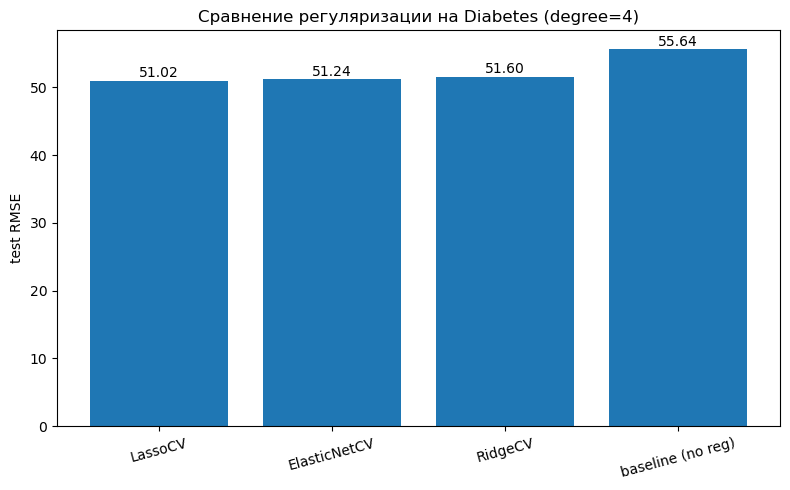

In [9]:
tab = table.sort_values('test_rmse')
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(tab['model'], tab['test_rmse'])
for bar, val in zip(bars, tab['test_rmse']):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5, f'{val:.2f}', ha='center')
ax.set_title('Сравнение регуляризации на Diabetes (degree=4)')
ax.set_ylabel('test RMSE')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


*Что мы здесь делали:* Графически показываем разницу. Хороший слайд для презентации заказчику: «вот что было без регуляризации, вот что стало после».

## Упражнение 9 — GridSearchCV

In [10]:
pipe_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('poly',   PolynomialFeatures(include_bias=False)),
    ('ridge',  Ridge()),
])
param_grid = {
    'poly__degree': [2, 3, 4],
    'ridge__alpha': np.logspace(-3, 2, 6),
}
grid = GridSearchCV(pipe_grid, param_grid, cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1)
grid.fit(X_train, y_train)
rmse_grid = np.sqrt(mean_squared_error(y_test, grid.predict(X_test)))
print('best params:', grid.best_params_)
print(f'test RMSE:   {rmse_grid:.3f}')


best params: {'poly__degree': 2, 'ridge__alpha': 100.0}
test RMSE:   51.596


*Что мы здесь делали:* `GridSearchCV` подбирает `degree` и `alpha` совместно. Внутри 3 × 6 = 18 моделей × 5 фолдов = 90 fit'ов. Зато результат заведомо не хуже ручных попыток.

## Упражнение 10 — Бизнес-вывод

In [11]:
# вывод: для эндокринолога я бы взял Lasso/ElasticNet — RMSE сравним с Ridge,
# но Lasso зануляет неважные биомаркеры; в отчёте остаются только те 5-10 фичей,
# которые реально связаны с прогрессией. Это сильно проще объяснить врачу.


*Что мы здесь делали:* В медицинских/банковских моделях интерпретируемость часто важнее +0.1% к RMSE. Lasso даёт «короткий список» фичей — это и есть его главная бизнес-ценность.

---

Готово. Регуляризация — обязательный инструмент для любого линрега в проде.